In [18]:
import sys
import torch

# Embeddings laden
embeddings = torch.load("../../util/knowledgegraph_embeddings/final_kg_embeddings_tensor.pt")  # [N, D]
# Namen/IDs der Knoten laden (z.B. aus dem Knowledge Graph)
import pickle
kg = pickle.load(open("../../util/knowledgegraph_embeddings/final_kg_with_embeddings_and_index_and_name.pkl", "rb"))
node_names = [kg.nodes[n]['name'] for n in kg.nodes]
node_types = [kg.nodes[n].get('type', 'unknown') for n in kg.nodes]

# Embedding für einen Suchbegriff erzeugen
from modules.KnowledgeExtraction.embedding import create_embedding
query = "Insulin"
query_emb = create_embedding(query)

# Kosinus-Ähnlichkeit berechnen
cos = torch.nn.functional.cosine_similarity(query_emb, embeddings)
topk = torch.topk(cos, 10)  # Die 10 ähnlichsten Knoten

print("Top 10 ähnliche Knoten zu:", query)
for idx in topk.indices:
    print(node_names[idx])

Top 10 ähnliche Knoten zu: Insulin
Insulin
Insulin
insuline
Insulin human
Insulin resistance
Glucagon
Insulin glulisine
Insulin lispro
Insulin tregopil
Insulin insensitivity


In [19]:
import torch
import numpy as np

def find_index(name):
    for i, n in enumerate(node_names):
        if name.lower() in n.lower():
            return i
    return None

idx_diabetes = find_index("diabetes")
idx_insulin = find_index("insulin")

if idx_diabetes is not None and idx_insulin is not None:
    emb_diabetes = embeddings[idx_diabetes]
    emb_insulin = embeddings[idx_insulin]
    cos_sim = torch.nn.functional.cosine_similarity(emb_diabetes, emb_insulin, dim=0)
    print(f"Kosinus-Ähnlichkeit zwischen Diabetes und Insulin: {cos_sim:.3f}")
else:
    print("Begriff nicht gefunden!")

Kosinus-Ähnlichkeit zwischen Diabetes und Insulin: 0.803


In [20]:
n = 500  # Starte mit 200–500 für schnelle Ergebnisse!
embeddings_np = embeddings[:n].numpy()
node_names_subset = node_names[:n]

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_np)

In [22]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_pca)

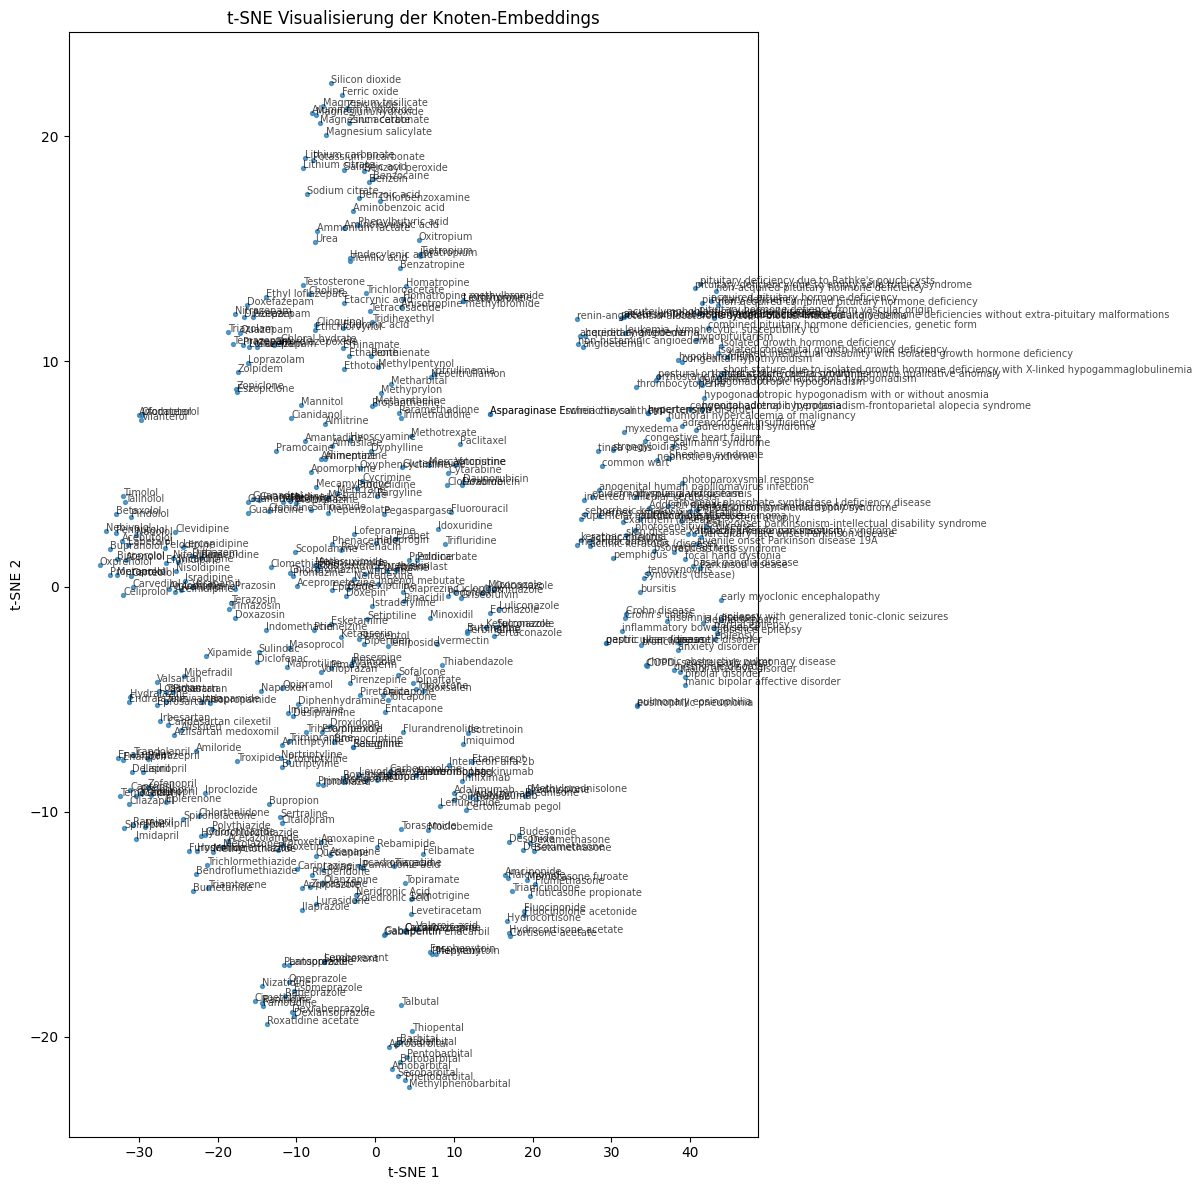

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=8, alpha=0.7)
for i, name in enumerate(node_names_subset):
    plt.annotate(name, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=7, alpha=0.7)
plt.title("t-SNE Visualisierung der Knoten-Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Parameter
subset_size = 500  # Anzahl der Knoten im Subset
begriffe = ["diabetes", "Insulin"]  # Begriffe, die immer enthalten sein sollen

In [25]:
print([b for b in begriffe if b not in node_names])

[]


In [26]:
from difflib import get_close_matches
print(get_close_matches("Diabetes", node_names, n=10))

['diabetes', 'diabetes', 'Diabetic', 'prediabetes', 'T2 diabetes', 'pre-diabetes', 'Diet', 'Diabetes Mellitus', 'Diabetes Mellitus', 'diabetic shoes']


In [27]:
# Annahme: node_names ist eine Liste mit allen Knotennamen

# 1. Indizes der Begriffe finden
begriffe_indices = [node_names.index(b) for b in begriffe]

# 2. Restliche Indizes zufällig auswählen (ohne die Begriffe)
other_indices = [i for i in range(len(node_names)) if i not in begriffe_indices]
random_indices = np.random.choice(other_indices, size=subset_size - len(begriffe), replace=False)

# 3. Subset-Indices zusammenstellen
subset_indices = np.array(begriffe_indices + list(random_indices))

In [28]:
# Annahme: all_embeddings ist ein NumPy-Array mit allen Embeddings
# Annahme: node_types ist eine Liste mit den Typen aller Knoten
all_embeddings = torch.load('final_kg_embeddings_tensor.pt')

embeddings_subset = all_embeddings[subset_indices]
node_types_subset = [node_types[i] for i in subset_indices]
node_names_subset = [node_names[i] for i in subset_indices]

In [29]:
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_subset)

In [30]:
import matplotlib.pyplot as plt

unique_types = list(set(node_types_subset))
# Erzeuge für jeden Typ eine eigene Farbe
farben = plt.cm.get_cmap('tab10', len(unique_types)).colors  # oder 'tab20' für mehr Farben

type_to_color = {typ: farbe for typ, farbe in zip(unique_types, farben)}
node_colors = [type_to_color[typ] for typ in node_types_subset]

/var/folders/bb/qyhd42qs7tj0cdb4wpzgsq1r0000gn/T/ipykernel_64492/1076939350.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  farben = plt.cm.get_cmap('tab10', len(unique_types)).colors  # oder 'tab20' für mehr Farben


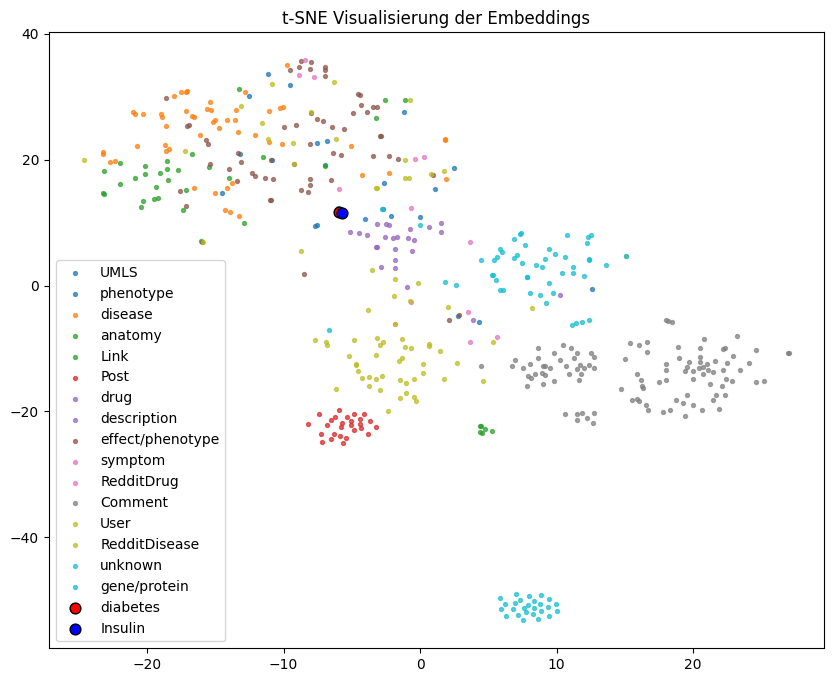

In [31]:
plt.figure(figsize=(10, 8))
for typ in unique_types:
    idx = np.array([i for i, t in enumerate(node_types_subset) if t == typ])
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], 
                s=8, alpha=0.7, label=typ, color=type_to_color[typ])

# Begriffe hervorheben
for name, color in zip(begriffe, ["red", "blue"]):
    idx = node_names_subset.index(name)
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], 
                s=60, color=color, label=name, edgecolor="black")

plt.legend()
plt.title("t-SNE Visualisierung der Embeddings")
plt.show()